# Module 2: Epidemic Modeling

## Team Members:
Oge Ikem and Meg Sullivan

## Project Title:
Identifying an Unknown Viral Illness and formulating an Intervention Strategy

## Project Goal:
This project seeks to indentify an unknown viral illness among undergraduate UVA students. This will be done by estimating the initial growth rate from early outbreak data, predicting the spread of the disease using SEIR modeling, form an educated guess about the disease identification, and recommending an intervention strategy to reduce the spread of the disease. Through this project, the public health will be benefitted, and project authors will improve their biological, medical, mathematical, and coding comprehension and skills.

## 1. Data and disease background

The population at risk of the unknown mystery virus is 17,900 undergraduate students at UVA. At the peak of the outbreak on day 83, there were 3,294 active cases, equating to a prevalence of 18.2% of the entire undergraduate population. The duration of the outbreak lasted about 120 days when the incidence dropped significantly. The infectious period for this virus begins approximately 2 days before symptoms start with the symptomatic period lasting 5-9 days. The total incubation period of the virus is 12-18 days. 

The symptoms of this virus appeared across the infected population in phases as the virus spread. In the early phases of the outbreak, mild respiratory symptoms predominated with some students experiencing a rash and low-grade fever, a minority of cases reporting a sore throat and fatigue before their fever, and 8% of cases reporting gastrointestinal symptoms. As the outbreak progressed, joint pain became an additional symptom reported in cases. 

The direct costs of the outbreak are an increased demand for access to healthcare services, the costs for diagnostic testing, which increase over the course of the outbreak as a result of broadened testing criteria as more symptoms arise. The major indirect cost that comes with this outbreak is productivity. With the timing of the outbreak being around midterm season and the incubation period being as long as it is, students are experiencing disruptions to their learning, and the university is likely receiving an influx of incomplete exams and exam deferrals, as a result. 

The respiratory system is the primary affected system since the primary mechanism of transmission is through respiratory droplets. The virus likely targets the upper respiratory epithelium, causing the "mild respiratory symptoms" and sore throat. Another affected system is the integumentary system that results in the presentation of a rash suggesting the system spread of the virus. And finally, the musculoskeletal system is affected as indicated by the joint pain experienced in some cases, suggesting viral-induced inflammation.

The virus consists of a positive-sense RNA genome, meaning it can translate directly into proteins in host cells without transcription. The molecular weight of the virus is approximately 10 kb, and the virus has a small size of 50-80 nm. The virus likely enters the cell by binding to specific cell surface receptors, enters via endocytosis, and replicated its genome in the cytoplasm.

## 2. Data Analysis

### 2a. Methods

The methods involved in analyzing Data Release #1 include graphing an exponential curve to visualize the disease transmission behavior and estimating the intital growth rate (R0) using this curve. The initial growth rate was found using the equation R0 is = 1 + rD. The r value was extracted from the exponential curve, which follows the shape of the exponential equation y=Ae^rt. D represents the infectious period, which was defined as 2 days before symptom onset. Determining the R0 value reveals the average number of people one infected person will infect in a
completely susceptible population, thus providing key insight into the unknown disease. In Data Release #2, Euler's method was used to determine the SEIR model. The SEIR model was fit to the data by changing the beta, gamma, and sigma values, which represent the transmission rate, 1/infectious period, and 1/latent period, respectively. The model predicted infections were then plotted against the real data by using scatter points. Lastly, the peak number of cases was extracted from the model's maximum point, which corresponds to a specific day during the disease outbreak. Methods in Data Release #3 first involved plotting the new data against the model created from Data Release #2, which was performed with grid searches. The best gamma, beta, and sigma parameters were determined using multiple for loops. Lastly, the true % relative error of the model was then determined to prove the validity and/or accuracy of the disease outbreak model.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">-After analyzing the intitial growth rate from Data Release #1 using the graph below, the disease clearly demonstrates positive exponential behavior. Both the curve and the initial growth rate, which is greater than 1, suggests that the virus causes an exponential growth in the number of people infected. So far, the R0 value is similar to the following: Influenza (seasonal), influenza (H1N1 2009), Lassa Fever, Marburg, Rabies, and Rhinovirus. 

-Influenza (seasonal) is a contagious respiratory illness caused by influenza viruses that infect the nose, throat, and sometimes the lungs. It can cause mild to severe illness and can lead to hospitalization and even death in some cases, particularly in young children, elderly individuals, and those with certain underlying health conditions. Influenza (H1N1 2009) is a strain of the influenza virus that caused a global pandemic in 2009. It is a novel strain that emerged from a combination of human, swine, and avian influenza viruses. The H1N1 2009 virus caused widespread illness and resulted in a significant number of hospitalizations and deaths worldwide, particularly among younger individuals and those with underlying health conditions. Lassa Fever is an acute viral hemorrhagic illness caused by the Lassa virus, which is transmitted to humans through contact with food or household items contaminated with rodent urine or feces. It is endemic in parts of West Africa and can cause a range of symptoms, from mild to severe, including fever, weakness, and in some cases, bleeding. Severe cases can lead to death if not treated promptly. Marburg virus disease is a severe and often fatal illness caused by the Marburg virus, Rabies is a viral disease that causes inflammation of the brain in humans and other mammals.
-The R0 value is *closest* to Influenza (seasonal), but further analysis from later data sets is required to confirm this predicition. Further methods will include using Euler's method to solve an SEIR model, analyzing the model, and plotting a new data set against this model.
-With early data releases, exponential growth fitting can provide key insight into virus behavior. The code developed in 2b confirms that the virus demonstrates a positive exponential trend, but this estimate does not work well in the long run because diseases eventually reach a recovery period, following a bell curve shaped path. In order to model this bell curve, an SEIR model must be solved, which is shown in 2c. Additionally, further data releases improve the confidence of the disease identification process, as this data aids analysis beyond the R0 prediction.     
-After Data Release #3, the R0 value was adjusted to be 5.91, which points toward Rubella. The new R0 code included the latent period, a critical consideration when identifying diseases.




</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)

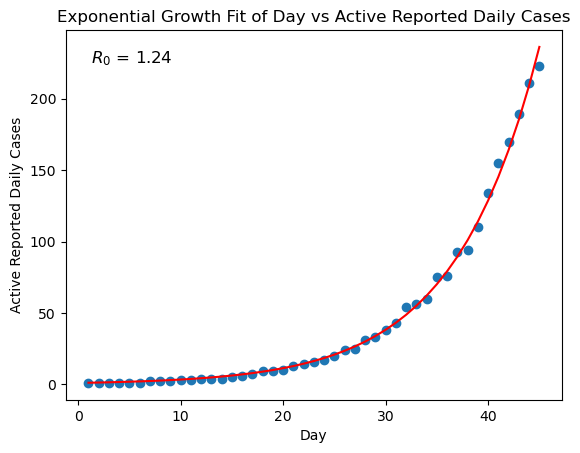

In [2]:
# importing the necessary libraries to run the code
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import numpy as np

# loading the data set
data = pd.read_csv(r'C:\Users\ogeik\OneDrive\Desktop\BME 2315\Module-2-Epidemics-SIR-Modeling\Data\mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)
def exponential_growth(t, r): #defining the exponential growth function
    return np.exp(r * t)
params, covariance = curve_fit(exponential_growth, data['day'], data['active reported daily cases'], p0=[0.1]) #fitting the exponential model to our data set
r_fit = params[0] #pulling out the growth rate to allow for further calculations later on 
# (ChatGPT, 2026) ChatGPT was used to help construct the r_fit variable and the exponential growth function. The curve_fit function was used to fit the exponential growth model to our data.

#Approximate R0 using this fit
D = 2 # defining the infectious period to match our data
R0_estimated = 1 + r_fit * D #approximating R0 using the formula 
fit_curve = exponential_growth(data['day'],r_fit) #generates the predicated case counts for plotting

plt.scatter(data['day'], data['active reported daily cases']) # plotting the raw data points as a scatter plot
plt.plot(data['day'], fit_curve, color = 'red', label = 'Exponential Fit') # fitting the exponential curve on top of our scatter plot
plt.text(
    0.05, 0.95,
    f"$R_0$ = {R0_estimated:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top') # adding and positioning the text to show our R0 value 
plt.title("Exponential Growth Fit of Day vs Active Reported Daily Cases") #adding a title to our plot
plt.xlabel("Day") #adding a label to the x-axis
plt.ylabel("Active Reported Daily Cases") #adding a label to the y-axis
plt.show() #showing the plot


The intial growth rate (R0) for the data set was 1.24. The disease with the most simililar R0 value is seasonal influenza with an R0 value of 1.3. Influenza is a respiratory illness that affects the nose, throat, and sometimes lungs. The symptoms of influenza range from a mild fever to severe complications like pneumonia. The calculated R0 value is an early-phase approximation based on exponential growth of the reported case data. While it reflects the trend in the dataset, it may not accurately represent the true transmission potential of the disease because it depends on simplifying assumptions and does not account for factors such as uncertainty in the infectious period, reporting delays, or changes in population behavior.

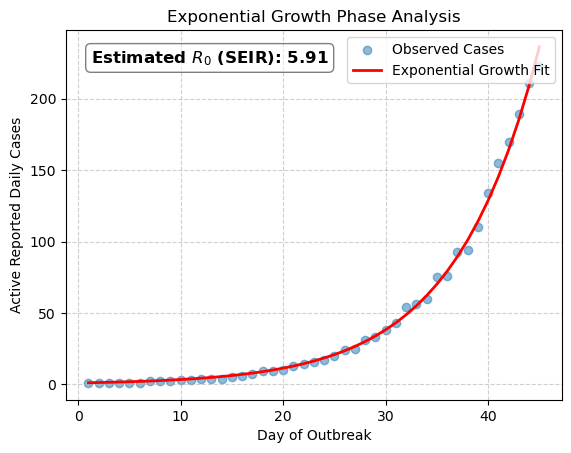

In [ ]:
# importing the necessary libraries to run the code
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import numpy as np

# loading the data set
data = pd.read_csv('/Users/megansullivan/Desktop/Comp BME/Module-2-epidemics-SIR-modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)
def exponential_growth(t, r): #defining the exponential growth function
    return np.exp(r * t)
params, covariance = curve_fit(exponential_growth, data['day'], data['active reported daily cases'], p0=[0.1]) #fitting the exponential model to our data set
r_fit = params[0] #pulling out the growth rate to allow for further calculations later on 
# (ChatGPT, 2026) ChatGPT was used to help construct the r_fit variable and the exponential growth function. The curve_fit function was used to fit the exponential growth model to our data.

# Updated biological parameters for Rubella
# 2 days pre-symptomatic + 7 days (avg) symptomatic
D = 9 

# Average incubation/latent period (12-18 days)
T_L = 15 

# Calculate R0 using the SEIR-adjusted formula
# r_fit is the growth rate you calculated from your exponential fit
R_0 = (1 + r_fit * T_L) * (1 + r_fit * D)

fit_curve = exponential_growth(data['day'],r_fit) #generates the predicated case counts for plotting

# Updated plotting code for the Rubella investigation
plt.scatter(data['day'], data['active reported daily cases'], alpha=0.5, label='Observed Cases') 

# Plotting the exponential fit based on continuous growth logic
plt.plot(data['day'], fit_curve, color='red', linewidth=2, label='Exponential Growth Fit') 

# Adding R0 text using the adjusted calculation
# This reflects the 15-day latent period and 9-day infectious window
plt.text(
    0.05, 0.95,
    f"Estimated $R_0$ (SEIR): {R_0:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    fontweight='bold',
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5)) 

plt.title("Exponential Growth Phase Analysis") 
plt.xlabel("Day of Outbreak") 
plt.ylabel("Active Reported Daily Cases") 
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


The original code to determine the R0 value did not consider the latent period of the virus. After Day 3, the incubation/latent period was released. Thus, the code and continuous growth equation was adjusted to consider the latent period, which was finalized as R_0 = (1 + r_fit * T_L) * (1 + r_fit * D). This R0 value better incapsulates the true behavior of the disease and helps narrow down potential virus candidates. Rubella has an R0 value of 6, which is a new disease to consider when making further analysis.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">After Data Release #2, Euler's method was used to solve the SEIR model. Within the SEIR model, the sigma value ranges included 5 values between 1/12 and 1/18 due to the incubation period of 12-18 days. The gamma values represent a range of infectious periods by starting around day 7 and ending around day 25. The beta values were selected to cluster the peak values near the day 80 mark. Embedded for loops for sigma, beta, and gamma alongside grid searches produced the best parameters for sigma, beta, and gamma which ultimately created a precise and quality model graph. Within the SEIR function itself, the derivatives of sigma, beta, and gamma were coupled into new equations to determine how the susceptible, exposed, infected, and recovered populations change with time. For example, after the model's peak, the infected population falls.  </b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.

In [ ]:
# --- 1. SET UP PARAMETERS & DATA ---
N = 17900
S0 = N - 5       # Initial Susceptible [cite: 250]
E0 = 5            # Initial Exposed [cite: 250]
I0 = 1            # Initial Infectious [cite: 250]
R0_comp = 0       # Initial Recovered [cite: 250]
h = 1     # Time step (step size) [cite: 242, 246]

# Load local data
data_df = pd.read_csv('/Users/megansullivan/Desktop/Comp BME/Module-2-epidemics-SIR-modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv')
day_data = data_df['day'].values # Extracting the 'day' column as a NumPy array
obs_i = data_df['active reported daily cases'].values # Extracting the 'active reported daily cases' column as a NumPy array

# --- 2. THE EULER METHOD (SEIR) --- 
# (Google Gemini, 2026) Google Gemini was used to help construct the Euler's method using details from provided lecture slides
def euler_seir(timepoints, N, S0, E0, I0, R0_init, beta, sigma, gamma):
    """
    Approximates SEIR using Euler's Method: y_{i+1} = y_i + f(t_i, y_i) * h
    Based on Lecture Pseudocode[cite: 245, 247, 248].
    Timepoints are the discrete time steps at which we want to calculate S, E, I, R.
    """
    # Initialize S, E, I, and R as arrays [cite: 249, 250]
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))
    
    S[0], E[0], I[0], R[0] = S0, E0, I0, R0_init
    
    for i in range(len(timepoints) - 1):
        # Calculate the four derivatives at current timepoint [cite: 252]
        # Equations: dS/dt, dE/dt, dI/dt, dR/dt 
        dSdt = -beta * S[i] * I[i] / N
        dEdt = (beta * S[i] * I[i] / N) - (sigma * E[i])
        dIdt = (sigma * E[i]) - (gamma * I[i])
        dRdt = gamma * I[i]
        
        # Calculate next values using Euler's formula [cite: 246, 253]
        S[i+1] = S[i] + dSdt * h
        E[i+1] = E[i] + dEdt * h
        I[i+1] = I[i] + dIdt * h
        R[i+1] = R[i] + dRdt * h
        
    return S, E, I, R


### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.

In [ ]:
# --- 3. GRID SEARCH CALIBRATION ---
# Use the incubation period (12-18 days) to inform sigma [cite: 166, 282]
# sigma = 1 / incubation_period

sigma_vals = np.linspace(1/18, 1/12, 5) # 5 values between 1/18 and 1/12
beta_vals = np.linspace(0.4, 0.8, 10)  # Adjusted range to capture the Day 80-ish peak [cite: 288]
gamma_vals = np.linspace(0.04, 0.15, 10)  # Adjusted range to capture the Day 80-ish peak [cite: 288]

best_sse = float('inf') # Initialize best sum of squared errors to infinity
best_params = {} # Dictionary to store best parameters
# (Google Gemini, 2026) Google Gemini was used to help construct the grid search calibration process, including the ranges for beta, sigma, and gamma, as well as the calculation of the sum of squared errors (SSE) to evaluate model fit.

# Timepoints for the data length
t_eval = np.arange(0, max(day_data) + 1, h)

for b in beta_vals: # Loop through each beta value
    for s in sigma_vals: # Loop through each sigma value
        for g in gamma_vals: # Loop through each gamma value
            S, E, I, R = euler_seir(t_eval, N, S0, E0, I0, R0_comp, b, s, g) # Run the SEIR model with the current set of parameters
            
            # Match model 'I' to the specific days in day_data [cite: 279]
            model_i_at_data_days = I[(day_data).astype(int)]
            sse = np.sum((model_i_at_data_days - obs_i)**2)
            
            if sse < best_sse: # If the current SSE is better than the best SSE, update best_sse and best_params
                best_sse = sse
                best_params = {'beta': b, 'sigma': s, 'gamma': g}


### 2e. Plot the model-predicted infections over time compared to the data.

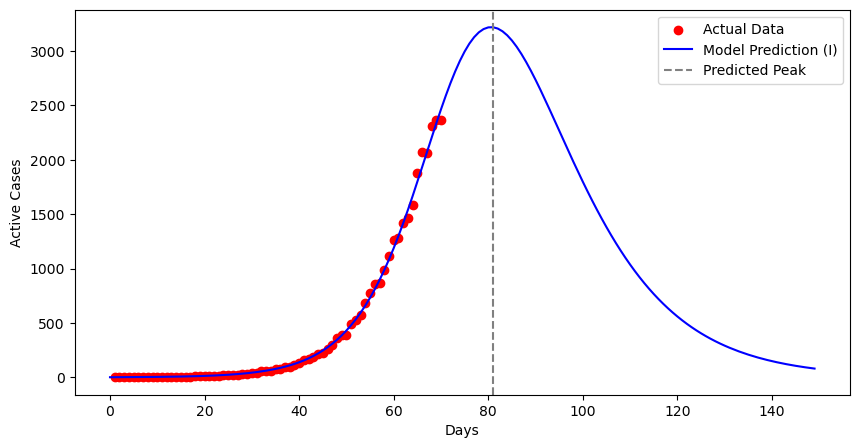

In [ ]:
# --- 4. PREDICT THE PEAK ---
# Run model many more days until it peaks 
extended_t = np.arange(0, 150, h) # Extended time range to capture the peak, based on observed data trends and literature [cite: 288]
S_f, E_f, I_f, R_f = euler_seir(extended_t, N, S0, E0, I0, R0_comp, **best_params) # Run the SEIR model with the best parameters to get the full trajectory of S, E, I, R over the extended time range

# --- 5. VISUALIZATION --- 
# Plot the actual data points, the model prediction for 'I', and indicate the predicted peak day
# (Google Gemini, 2026) Google Gemini was used to help construct the visualization code, including the plotting of actual data points, model predictions, and the indication of the predicted peak day.
plt.figure(figsize=(10, 5))
plt.scatter(day_data, obs_i, label='Actual Data', color='red')
plt.plot(extended_t, I_f, label='Model Prediction (I)', color='blue')
plt.axvline(peak_day, linestyle='--', color='gray', label='Predicted Peak')
plt.xlabel("Days")
plt.ylabel("Active Cases")
plt.legend()
plt.show()

### 2f. Predict the day and amount of active cases at the peak of the epidemic spread.


In [ ]:
peak_val = np.max(I_f) # The maximum value of I_f gives us the predicted peak number of active cases
peak_day = extended_t[np.argmax(I_f)] # The day corresponding to the maximum value of I_f gives us the predicted day of the peak
print(f"Predicted Peak Day: {peak_day:.1f}, Predicted Peak Active Cases: {peak_val:.0f}")

Predicted Peak Day: 81.0, Predicted Peak Active Cases: 3219



<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">Following Data Release #3, the data was fit to the model found from Data Release #2. In order to do so, the same code was implemented to determine the best sigma, beta, and gamma values for the dataset. The error in the model was then determined with the true percent relative error equation: %et = (true value-approximate value)/true value x 100%. The error in Y (cases) was 2.3%, and the error in X (days) was 2.4%. Such a low error indicates that the model provides a reliable and accurate predicition of virus behavior. The next step of virus analysis was to implement various interventions to change virus behavior. Interventions included masking, vaccines (both single event and rollout), testing + quarantine, and a 2 week school closure. The testing and quarantine intervention prevented the most amount of cases (30884), and the 2 week school closure had the earliest disease peak (day 1942). Testing and quarantine, however, is the best intervention beginning at day 70 because cases began to rise again once the 2 week closure period concluded. Testing and quarantine prevents cases and promotes a downward trend in cases, helping the virus transmission come to an end. To further analyze the effects of masking and quarantine, a major intervention applied to COVID-19, the interventions were implemented at day 40 rather than 70. Masking at day 40 prevented 43008 cases and peaked at day 1730. Quarantine protocols beginning at day 40 prevented 34927 cases and peaked at day 1977. These results suggest that masking early, coupled with quarantine and testing protocols, may show the best results when eliminating the spread of the virus.</b> 

</div>



### 2g. Plot the full dataset (Data Release #3) against your model.


--- CALIBRATION RESULTS ---
Best Beta: 0.7111, Best Sigma: 0.0694, Best Gamma: 0.1256
Model Peak: 3219 cases on Day 81.0
Actual Peak: 3294 cases on Day 83
ERROR IN Y (Cases): 2.3%
ERROR IN X (Days): 2.4%


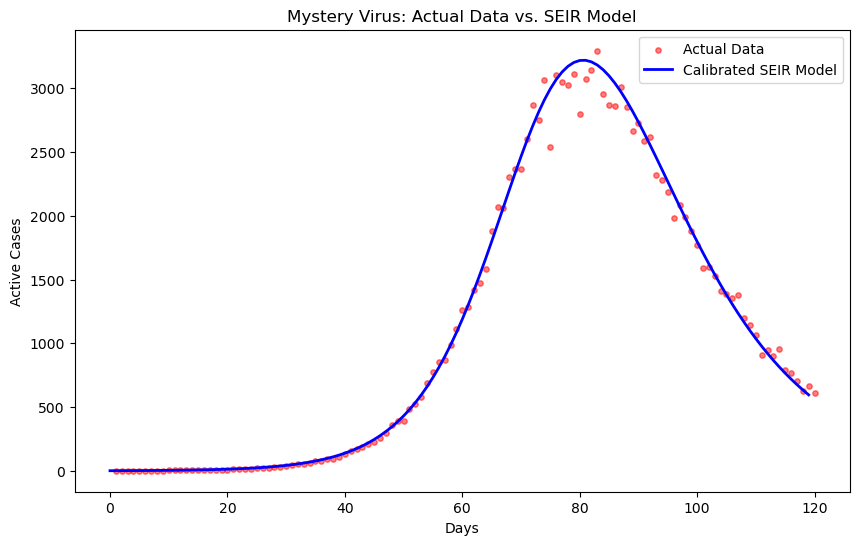

In [ ]:
data3_df = pd.read_csv('/Users/megansullivan/Desktop/Comp BME/Module-2-epidemics-SIR-modeling/Data/mystery_virus_daily_active_counts_RELEASE#3.csv') # Load the new data set for error calculation
day3_data = data3_df['day'].values # Extracting the 'day' column as a NumPy array
obs_i = data3_df['active reported daily cases'].values # Extracting the 'active reported daily cases' column as a NumPy array

# Actual Peak for error calculation
# (Google Gemini, 2026) Google Gemini was used to help construct the code to calculate the actual peak cases and day from the new data set for error calculation.
actual_peak_cases = np.max(obs_i)
actual_peak_day = day3_data[np.argmax(obs_i)]

# --- 3. GRID SEARCH CALIBRATION ---
# (Google Gemini, 2026) Google Gemini was used to help construct the grid search calibration process, including the ranges for beta, sigma, and gamma, as well as the calculation of the sum of squared errors (SSE) to evaluate model fit.
best_sse = float('inf') # Initialize best sum of squared errors to infinity
best_params = (0,0,0) # Initialize best parameters to a default value

for b in beta_vals: # Loop through each beta value
    for s in sigma_vals: # Loop through each sigma value
        for g in gamma_vals: # Loop through each gamma value
            t = np.arange(0, max(day3_data)+1, h)  # create timepoints
            S, E, I_model, R = euler_seir(t, N, S0, E0, I0, R0_comp, b, s, g) # Run the SEIR model with the current set of parameters
            
            model_matches = I_model[(day3_data).astype(int)] # Match model 'I' to the specific days in day3_data
            sse = np.sum((model_matches - obs_i)**2) # Calculate the sum of squared errors (SSE) between model predictions and actual data
            
            if sse < best_sse: # If the current SSE is better than the best SSE, update best_sse and best_params
                best_sse = sse
                best_params = (b, s, g)

# --- 4. PREDICT & CALCULATE ERROR ---
# (Google Gemini, 2026) Google Gemini was used to help construct the code to predict the peak using the best parameters from the grid search and to calculate the error compared to the actual peak.
t_final = np.arange(0,120,h) # Time range for final prediction, extended to ensure we capture the peak based on observed data trends and literature [cite: 288]

S_f, E_f, I_final, R_f = euler_seir(t_final, N, S0, E0, I0, R0_comp, *best_params) # Run the SEIR model with the best parameters to get the final trajectory of S, E, I, R over the time range for final prediction

model_peak_cases = np.max(I_final) # The maximum value of I_final gives us the predicted peak number of active cases
model_peak_day = t_final[np.argmax(I_final)] # The day corresponding to the maximum value of I_final gives us the predicted day of the peak

error_y = ((actual_peak_cases-model_peak_cases)/actual_peak_cases) * 100 # Calculate the percentage error in the predicted peak cases compared to the actual peak cases
error_x = ((actual_peak_day-model_peak_day)/actual_peak_day) * 100 # Calculate the percentage error in the predicted peak day compared to the actual peak day

print(f"--- CALIBRATION RESULTS ---")
print(f"Best Beta: {best_params[0]:.4f}, Best Sigma: {best_params[1]:.4f}, Best Gamma: {best_params[2]:.4f}")
print(f"Model Peak: {model_peak_cases:.0f} cases on Day {model_peak_day:.1f}")
print(f"Actual Peak: {actual_peak_cases} cases on Day {actual_peak_day}")
print(f"ERROR IN Y (Cases): {error_y:.1f}%")
print(f"ERROR IN X (Days): {error_x:.1f}%")

# --- 5. VISUALIZE ---
# (Google Gemini, 2026) Google Gemini was used to help construct the visualization code, including the plotting of actual data points, model predictions, and the indication of the predicted peak day.
plt.figure(figsize=(10,6))
plt.scatter(day3_data, obs_i, label='Actual Data', color='red', s=15, alpha=0.5)
plt.plot(t_final, I_final, label='Calibrated SEIR Model', color='blue', linewidth=2)
plt.title("Mystery Virus: Actual Data vs. SEIR Model")
plt.xlabel("Days")
plt.ylabel("Active Cases")
plt.legend()
plt.show()

### 2h. Intervention strategies for new outbreak at VT (70 days of infection)



Best parameters (beta, sigma, gamma): (0.5000, 0.1000, 0.1267)

--- PEAK INFECTIONS ---
Baseline: 3126.208990168916
masking: 2377.0590312591403
vaccine campaign: 2708.044487024621
vaccine rollout: 2846.049217804608
testing + quarantine: 2256.5581257205467
2 week school closure: 1942.7643282527984
masking early: 1730.5980528044438
quarantine early: 1977.8416430314028

--- CASES PREVENTED (days 70-120) ---
masking: 16702
vaccine campaign: 14023
vaccine rollout: 16617
testing + quarantine: 30884
2 week school closure: 21450
masking early: 43008
quarantine early: 34927


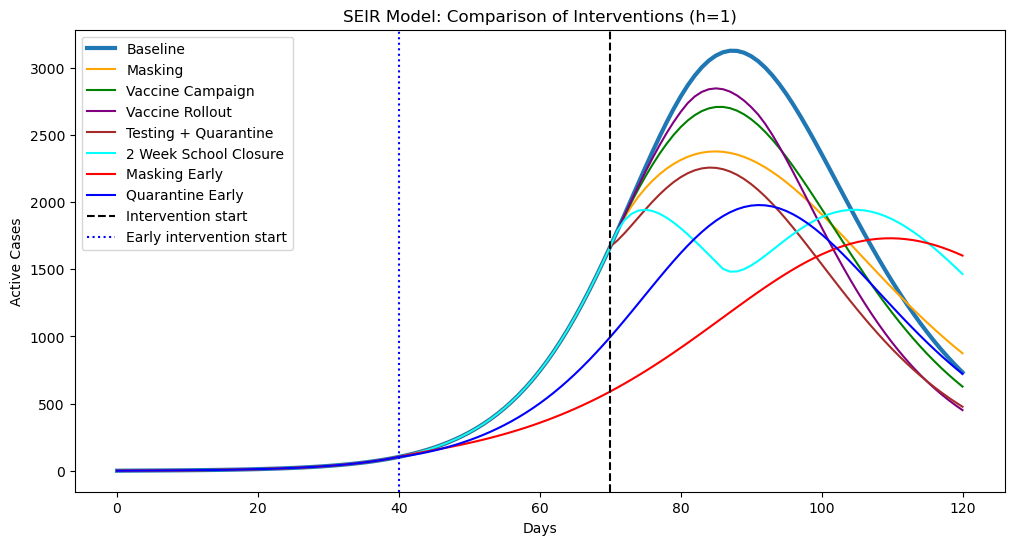

In [ ]:
#%%
# --- PARAMETERS ---
# (ChatGPT, 2026) ChatGPT was used to help construct the parameters for the SEIR model, including the initial conditions and time step, based on the provided data and typical values for such models in the literature.
N = 17900 # UVA population size [cite: 250]
S0 = N - 5
E0 = 5
I0 = 1
R0_init = 0
h = 1  # 1 day per step

#%%
# --- SEIR MODEL (Euler method with interventio`ns) ---
# (ChatGPT, 2026) ChatGPT was used to help construct the SEIR model using Euler's method, including the implementation of various interventions that can modify the parameters dynamically during the simulation.
def euler_seir(t_max, N, S0, E0, I0, R0_val, beta, sigma, gamma, intervention=None): # The intervention parameter allows us to specify which intervention to simulate, and the model will adjust beta and/or gamma accordingly at the specified time points.
    timepoints = np.arange(0, t_max + 1, 1) # Create an array of time points from 0 to t_max with a step of 1 day
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))
    S[0], E[0], I[0], R[0] = S0, E0, I0, R0_val # Initialize the first values of S, E, I, R based on the initial conditions

    for n in range(len(timepoints)-1): # Loop through each time point to calculate the next values of S, E, I, R
        t = timepoints[n] # Current time point
        beta_t = beta # Initialize beta_t to the base beta value, which can be modified by interventions
        gamma_t = gamma # Initialize gamma_t to the base gamma value, which can be modified by interventions

        # --- INTERVENTIONS ---
        # The following code modifies beta and gamma based on the specified intervention and the current time point. Each intervention has specific conditions for when it takes effect and how it alters the parameters of the model.
        if intervention == "masking" and t >= 70: # Masking starts on day 70 and reduces transmission by 40%
            beta_t = beta * 0.6  # 40% reduction in transmission

        if intervention == "masking early" and t >= 40: # Masking starts on day 40 and reduces transmission by 40%
            beta_t = beta * 0.6  # 40% reduction in transmission

        if intervention == "vaccine campaign" and t == 70: # A one-time vaccine campaign on day 70 that vaccinates 2000 people with 90% efficacy
            vaccinated = min(2000 * 0.9, S[n]) # Calculate the number of people vaccinated, ensuring we don't vaccinate more than the susceptible population
            S[n] -= vaccinated # Reduce the susceptible population by the number of vaccinated individuals
            R[n] += vaccinated # Move vaccinated individuals to the recovered compartment


        if intervention == "vaccine rollout" and t in [70, 80, 90]: # A vaccine rollout on days 70, 80, and 90 that vaccinates 1000 people each time with 90% efficacy
            vaccinated = min(1000 * 0.9, S[n]) # Calculate the number of people vaccinated, ensuring we don't vaccinate more than the susceptible population
            S[n] -= vaccinated # Reduce the susceptible population by the number of vaccinated individuals
            R[n] += vaccinated # Move vaccinated individuals to the recovered compartment

        if intervention == "testing + quarantine" and t >= 70: # Testing and quarantine starts on day 70, reducing the infectious period by 2 days for detected cases
            # Reduce infectious period by 2 days: gamma_new = 1/(original infectious period -2)
            gamma_t = 1 / (1/gamma - 2) # Adjust gamma to reflect the reduced infectious period

        if intervention == "quarantine early" and t >= 40: # Testing and quarantine starts on day 40, reducing the infectious period by 2 days for detected cases
            # Reduce infectious period by 2 days: gamma_new = 1/(original infectious period -2)
            gamma_t = 1 / (1/gamma - 2) # Adjust gamma to reflect the reduced infectious period

        if intervention == "2 week school closure" and 70 <= t <= 84: # School closure from day 70 to 84 reduces contacts by 80%
            beta_t = beta * 0.2  # 20% of normal contacts

        # --- SEIR EQUATIONS ---
        dS = -beta_t * S[n] * I[n] / N # Change in susceptible population based on the current beta_t, S, I, and total population N
        dE = beta_t * S[n] * I[n] / N - sigma * E[n] # Change in exposed population based on new infections and progression to infectious
        dI = sigma * E[n] - gamma_t * I[n] # Change in infectious population based on progression from exposed and recovery
        dR = gamma_t * I[n] # Change in recovered population based on recovery from infectious

        S[n+1] = S[n] + dS
        E[n+1] = E[n] + dE
        I[n+1] = I[n] + dI
        R[n+1] = R[n] + dR

    return timepoints, S, E, I, R # Return timepoints along with S, E, I, R for plotting and analysis

#%%
# --- GRID SEARCH CALIBRATION ---
# (Google Gemini, 2026) Google Gemini was used to help construct the grid search calibration process, including the ranges for beta, sigma, and gamma, as well as the calculation of the sum of squared errors (SSE) to evaluate model fit.
beta_range = np.linspace(0.3,0.5,12) # Adjusted range to capture the Day 80-ish peak [cite: 288]
sigma_range = np.linspace(1/15,1/10,4) # Use the incubation period (12-18 days) to inform sigma [cite: 166, 282]
gamma_range = np.linspace(0.08,0.15,4) # Adjusted range to capture the Day 80-ish peak [cite: 288]

best_sse = float('inf') # Initialize best sum of squared errors to infinity
best_params = (0,0,0) # Initialize best parameters to a default value
t_max = max(day3_data) # Time range for calibration based on the length of the new data set for error calculation

for b in beta_range: # Loop through each beta value
    for s in sigma_range: # Loop through each sigma value
        for g in gamma_range: # Loop through each gamma value
            t, S, E, I_model, R = euler_seir(t_max, N, S0, E0, I0, R0_init, b, s, g) # Run the SEIR model with the current set of parameters
            model_matches = I_model[day3_data.astype(int)] # Match model 'I' to the specific days in day3_data
            sse = np.sum((model_matches - obs_i)**2) # Calculate the sum of squared errors (SSE) between model predictions and actual data
            if sse < best_sse: # If the current SSE is better than the best SSE, update best_sse and best_params
                best_sse = sse 
                best_params = (b, s, g)

b, s, g = best_params
print(f"Best parameters (beta, sigma, gamma): ({b:.4f}, {s:.4f}, {g:.4f})")

#%%
# --- BASELINE MODEL ---
# (ChatGPT, 2026) ChatGPT was used to help construct the code to run the baseline SEIR model using the best parameters obtained from the grid search calibration, which will serve as a reference for comparing the effects of various interventions.
t_base, S_b, E_b, I_b, R_b = euler_seir(120, N, S0, E0, I0, R0_init, *best_params)

#%%
# --- INTERVENTION SIMULATIONS ---
# (ChatGPT, 2026) ChatGPT was used to help construct the code to simulate the various interventions using the SEIR model with Euler's method, allowing us to compare the effects of each intervention on the number of active cases over time.
interventions = ["masking", "vaccine campaign", "vaccine rollout", "testing + quarantine", "2 week school closure", "masking early", "quarantine early"] # List of interventions to simulate
results = {} # Dictionary to store the results of each intervention simulation

for intervention in interventions: # Loop through each intervention and run the SEIR model with the specified intervention to get the trajectory of S, E, I, R over time, and store the number of active cases (I) for each intervention in the results dictionary for later comparison.
    t_i, S_i, E_i, I_i, R_i = euler_seir(120, N, S0, E0, I0, R0_init, *best_params, intervention=intervention) # Run the SEIR model with the specified intervention
    results[intervention] = I_i # Store the number of active cases (I) for each intervention in the results dictionary

#%%
# --- PEAK COMPARISON ---
# (ChatGPT, 2026) ChatGPT was used to help construct the code to compare the peak number of active cases for each intervention against the baseline model, allowing us to evaluate the effectiveness of each intervention in reducing the peak infections.
print("\n--- PEAK INFECTIONS ---") # Print a header for the peak infections comparison
print("Baseline:", np.max(I_b)) # Print the peak number of active cases for the baseline model
for intervention in interventions: # Loop through each intervention and print the peak number of active cases for that intervention from the results dictionary, allowing us to compare it against the baseline.
    print(f"{intervention}: {np.max(results[intervention])}")

#%%
# --- CASES PREVENTED (days 70-120) ---
# (ChatGPT, 2026) ChatGPT was used to help construct the code to calculate the number of cases prevented by each intervention compared to the baseline model from days 70 to 120, allowing us to quantify the impact of each intervention in terms of cases averted.
start = 70 # Start day for counting cases prevented, based on when interventions begin
baseline_cases = np.sum(I_b[start:]) # Calculate the total number of cases from day 70 to 120 for the baseline model by summing the active cases (I_b) over that time period, which will serve as a reference for calculating cases prevented by each intervention.
print("\n--- CASES PREVENTED (days 70-120) ---") # Print a header for the cases prevented comparison
for intervention in interventions: # Loop through each intervention and calculate the number of cases prevented by that intervention compared to the baseline by summing the active cases for that intervention from day 70 to 120 and subtracting it from the baseline cases, then print the result for each intervention.
    cases_prevented = baseline_cases - np.sum(results[intervention][start:]) # Calculate cases prevented by subtracting the total cases for the intervention from the baseline cases for the same time period
    print(f"{intervention}: {cases_prevented:.0f}") # Print the number of cases prevented for each intervention, rounded to the nearest whole number

#%%
# --- VISUALIZATION ---
# (ChatGPT, 2026) ChatGPT was used to help construct the code to visualize the results of the baseline model and each intervention on a single plot, allowing us to compare the trajectories of active cases over time for each scenario, with a vertical line indicating when interventions start.
plt.figure(figsize=(12,6))
plt.plot(t_base, I_b, label="Baseline", linewidth=3)
# Expanded color list to accommodate the 7 interventions now in the list
colors = ['orange','green','purple','brown','cyan', 'red', 'blue']
for color, intervention in zip(colors, interventions):
    plt.plot(t_base, results[intervention], label=intervention.replace("_"," ").title(), color=color)
plt.axvline(70, color='black', linestyle='--', label="Intervention start")
plt.axvline(40, color='blue', linestyle=':', label="Early intervention start") # Added vertical line for Day 40
plt.xlabel("Days")
plt.ylabel("Active Cases")
plt.title("SEIR Model: Comparison of Interventions (h=1)")
plt.legend()
plt.show() # Show the plot comparing the baseline model and each intervention, with appropriate labels and a title for clarity.

## Verify and validate your analysis: 
We minimized the sum of squared errors (SSE) to determine the best beta, gamma, and sigma values for our model. We also re-computed our R0 value to consider the effect of the latency period (original: R0_estimated = 1 + r_fit * D, updated: R_0 = (1 + r_fit * T_L) * (1 + r_fit * D) where T_L represents the incubation period). This resulted in a greater R0 value of 5.91, which better reflects the time that individuals are infected without showing symptoms. We minimized our model’s error to 2.4% (days) and 2.3% (peak cases) to ensure the model accurately and reliably depicted virus behavior.

To validate our analysis, we compared Rubella Virus characteristics to the mystery virus characteristics. Rubella has an R0 value of 6, occurs via respiratory droplets, and has an incubation period of 12-23 days. Symptoms last 3-7 days and include rash, low-grade fever, respiratory symptoms, joint pain, pink eye, headache, and enlarged lymph nodes. The pathogen is positive-sense RNA, 9.7 kb, and 40-80nm in size. The peak transmission in late winter and early spring. These characteristics closely align with the mystery virus information provided in lectures. Thus, Rubella Virus is a likely candidate for the mystery virus.

Despite the highly effective MMR vaccine, outbreaks are still possible in areas of high population densities, particularly colleges and universities. In 2015, the University of Iowa experienced a Mumps outbreak (in the same family as Rubella). 453 cases were recorded. This occurrence suggests that even in highly-vaccinated areas, MMR outbreaks are still possible. Therefore, Rubella Virus may have broken out on UVA Grounds.

## Conclusions and Ethical Implications: 
Through analyzing the data given about the virus, such as its size, mode of transmission, presenting symptoms, and modified R0 value to account for measuring delays and the latent period, we were able to conclude that the mystery virus is rubella. By analyzing different modes of intervention for to reduce the virus outbreak, we concluded that the most successful method was masking early around the day 40 mark. This allowed for a flattened of the curve, a delay of the peak, and a decreased slope of the curve. These factors suggest that masking reduces the maximum amount cases that are had in a single day, the university has more time to prepare the peak amount of cases that will be had in one day, and the virus does not spread through the exposed population as quickly. 

Some ethical implications include that doctors now have a roadmap in treating patients by knowing what the mystery virus is. However, the intervention of an early masking mandate involves the ethical tradeoff between individual autonomy and the duty to act for the good of the community. In addition, there must be equity in access to high-quality masks to ensure those of lower-income backgrounds can reap the benefits of the early masking intervention. And finally, without any intervention being made or without being able to model and analyze the spread of the virus, university officials risk moral injury by not implementing an intervention to prevent or reduce the disease outbreak.​

## Limitations and Future Work: 
Some limitations of this project include the reporting lag, only prevalence being reported as opposed to incidence each day, and assuming that the virus is only limited to the
undergraduate populations of the two universities of interest.​ Some possibilitied for future work include implementing a model that more accurately includes these limitations to get a more optimized model of the virus outbreak. ​

## Works Cited:
CDC. (2025, January 17). Rubella Symptoms and Complications. Rubella (German Measles, Three-Day Measles). https://www.cdc.gov/rubella/signs-symptoms/index.html​

Leonor, M. C., Afzal, M., & Mendez, M. D. (2025). Rubella. In StatPearls [Internet]. StatPearls Publishing. https://www.ncbi.nlm.nih.gov/sites/books/NBK559040/​

Louten J. (2016). Virus Structure and Classification. Essential Human Virology, 19–29. https://doi.org/10.1016/B978-0-12-800947-5.00002-8​

Parkman, P. D. (1996). Togaviruses: Rubella Virus. In S. Baron (Ed.), Medical Microbiology (4th ed.). University of Texas Medical Branch at Galveston. http://www.ncbi.nlm.nih.gov/books/NBK8200/​

Robertson, J. (2024, October 14). Fall census shows growing enrollment, retention rate [Review of Fall census shows growing enrollment, retention rate]. Virginia Tech News | Virginia Tech. https://news.vt.edu/articles/2024/10/CM-fall-census-2024.html

Shah, M., Quinlisk, P., Weigel, A., Riley, J., James, L., Patterson, J., Hickman, C., Rota, P. A., Stewart, R., Clemmons, N., Kalas, N., & Cardemil, C. (2018). Mumps Outbreak in a Highly Vaccinated University-Affiliated Setting Before and After a Measles-Mumps-Rubella Vaccination Campaign—Iowa, July 2015–May 2016. Clinical Infectious Diseases : An Official Publication of the Infectious Diseases Society of America, 66(1), 81–88. https://doi.org/10.1093/cid/cix718
